In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [103]:
BCdata = pd.read_csv('../Dataset/Air Pollutant Data/_processed/BC_2022_2025_combined.csv', header=0)


In [104]:
print(BCdata.head())
print(BCdata.info())

         Date      Time  PM25 PM25_method  PM25_n_sources  \
0  12/31/2023  24:00 AM  10.1        PM25               1   
1    1/1/2024   1:00 AM   7.8        PM25               1   
2    1/1/2024   2:00 AM   6.8        PM25               1   
3    1/1/2024   3:00 AM   7.0        PM25               1   
4    1/1/2024   4:00 AM   5.6        PM25               1   

                        Station  
0  Abbotsford_A_Columbia_Street  
1  Abbotsford_A_Columbia_Street  
2  Abbotsford_A_Columbia_Street  
3  Abbotsford_A_Columbia_Street  
4  Abbotsford_A_Columbia_Street  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2349604 entries, 0 to 2349603
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   Date            object 
 1   Time            object 
 2   PM25            float64
 3   PM25_method     object 
 4   PM25_n_sources  int64  
 5   Station         object 
dtypes: float64(1), int64(1), object(4)
memory usage: 107.6+ MB
None


In [105]:
# find and remove duplicated rows
BCdata = BCdata.drop_duplicates()
print(len(BCdata))

2349439


In [106]:
# Create a function to convert time to 24-hour format
def convert_to_24h(time_str):
    time_part, am_pm = time_str.split(' ')
    hours, minutes = map(int, time_part.split(':'))
    
    # Handle "24:00 AM" as special case
    if hours == 24 and am_pm == 'AM':
        return "00:00"
    
    # Convert to 24-hour format
    if am_pm == 'PM' and hours != 12:
        hours += 12
    elif am_pm == 'AM' and hours == 12:
        hours = 0
    
    return f"{hours:02d}:{minutes:02d}"

# Apply conversion
BCdata['Time_24h'] = BCdata['Time'].apply(convert_to_24h)

# Now combine date and 24-hour time
BCdata['datetime'] = pd.to_datetime(BCdata['Date'] + ' ' + BCdata['Time_24h'], format='%m/%d/%Y %H:%M')

BCdata.drop(columns=['Time_24h', 'Date', 'Time'], inplace=True)


In [ ]:
BCdata.to_csv('BC_2022_2025_combined.csv', index=False)

In [107]:
station_groups = {}
for station_name, station_data in BCdata.groupby('Station'):
    station_groups[station_name] = station_data
    
print(f"Total number of stations: {len(station_groups)}")
print(f"total number of records: {len(BCdata)}")

Total number of stations: 67
total number of records: 2349439


## 1. missing value analysis

Text(0, 0.5, 'Proportion of Missing PM2.5 Values')

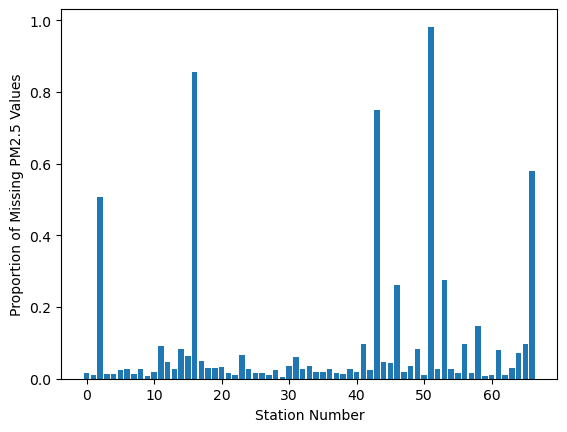

In [23]:
# find nans in each station
nans_list = []
station_names = []
for station_name, station_data in station_groups.items():
    nans = station_data.isna().sum()['PM25']/len(station_data)
    station_names.append(station_name)
    nans_list.append(nans)
        
plt.bar(np.arange(len(nans_list)), nans_list)
plt.xlabel('Station Number') 
plt.ylabel('Proportion of Missing PM2.5 Values')

In [21]:
most_missing_station = station_names[np.argmax(nans_list)]
print(f"Station with most missing PM2.5 values: {most_missing_station} with {max(nans_list)*100:.2f}% missing values.")

Station with most missing PM2.5 values: Skookumchuck_Farstad_Way with 98.25% missing values.


In [29]:
# top 10 stations with the most missing values
top_10_indices = np.argsort(nans_list)[-10:]
top_10_stations = [station_names[i] for i in top_10_indices]
print("Top 10 stations with most missing PM2.5 values:")
print(pd.DataFrame(np.vstack((top_10_stations, np.array(nans_list)[top_10_indices]*100)).T, columns=['Station', 'Missing PM2.5 (%)']))

Top 10 stations with most missing PM2.5 values:
                            Station   Missing PM2.5 (%)
0    North_Vancouver_Second_Narrows    9.63271358503479
1  Williams_Lake_Columneetza_School   9.724917246889625
2                         Valemount  14.794114292232235
3          Port_Edward_Sunset_Drive   26.19196988707654
4        Sparwood_Centennial_Square  27.620622790007985
5           Agassiz_Centennial_Park   50.68153302155811
6                 Willow_Creek_Mine  58.101561609483646
7             Penticton_Debeck_Road   75.10836089882514
8         Farmington_Community_Hall   85.66499372647428
9          Skookumchuck_Farstad_Way   98.24626440059313


In [108]:
# drop stations with more than 50% missing values
stations_to_keep = [station_name for station_name, nans in zip(station_names, nans_list) if nans <= 0.2]
cleaned_data = BCdata[BCdata['Station'].isin(stations_to_keep)].reset_index(drop=True)
print(f"Number of stations after cleaning: {len(stations_to_keep)}")

cleaned_station_groups = {}
for station_name, station_data in cleaned_data.groupby('Station'):
    cleaned_station_groups[station_name] = station_data

Number of stations after cleaning: 60


## 2. Overall PM2.5 analysis

## 3. correlation analysis

In [97]:
# find the duplicated datetime entries in each station
for station_name, station_data in cleaned_station_groups.items():
    duplicated_datetimes = station_data[station_data.duplicated(subset=['datetime'], keep=False)]
    if not duplicated_datetimes.empty:
        print(f"Station: {station_name} has duplicated datetime entries:")
        print(duplicated_datetimes)


In [98]:
print(cleaned_data.head())

   PM25 PM25_method  PM25_n_sources                       Station  \
0  10.1        PM25               1  Abbotsford_A_Columbia_Street   
1   7.8        PM25               1  Abbotsford_A_Columbia_Street   
2   6.8        PM25               1  Abbotsford_A_Columbia_Street   
3   7.0        PM25               1  Abbotsford_A_Columbia_Street   
4   5.6        PM25               1  Abbotsford_A_Columbia_Street   

             datetime  
0 2023-12-31 00:00:00  
1 2024-01-01 01:00:00  
2 2024-01-01 02:00:00  
3 2024-01-01 03:00:00  
4 2024-01-01 04:00:00  


In [109]:
# transform data to wide format for correlation analysis
def create_station_wide_dataframe(station_groups):
    wide_dfs = []
    
    for station_name, station_df in station_groups.items():
        
        # create a wide format dataframe for each station
        station_wide = station_df[['datetime', 'PM25']].copy()
        
        # Handle duplicate datetimes by taking the mean
        station_wide = station_wide.groupby('datetime')['PM25'].mean().to_frame()
        station_wide = station_wide.rename(columns={'PM25': station_name})
        wide_dfs.append(station_wide)
    
    # Merge all station data
    combined = pd.concat(wide_dfs, axis=1)
    
    # Resample if needed to unify time frequency
    # combined = combined.resample('H').mean()  # hourly average
    # combined = combined.resample('D').mean()  # daily average
    
    return combined

# Create wide format data
wide_df = create_station_wide_dataframe(cleaned_station_groups)

# Calculate correlation matrix
correlation_matrix = wide_df.corr()
#print("PM2.5 correlation matrix between stations:")
#print(correlation_matrix)


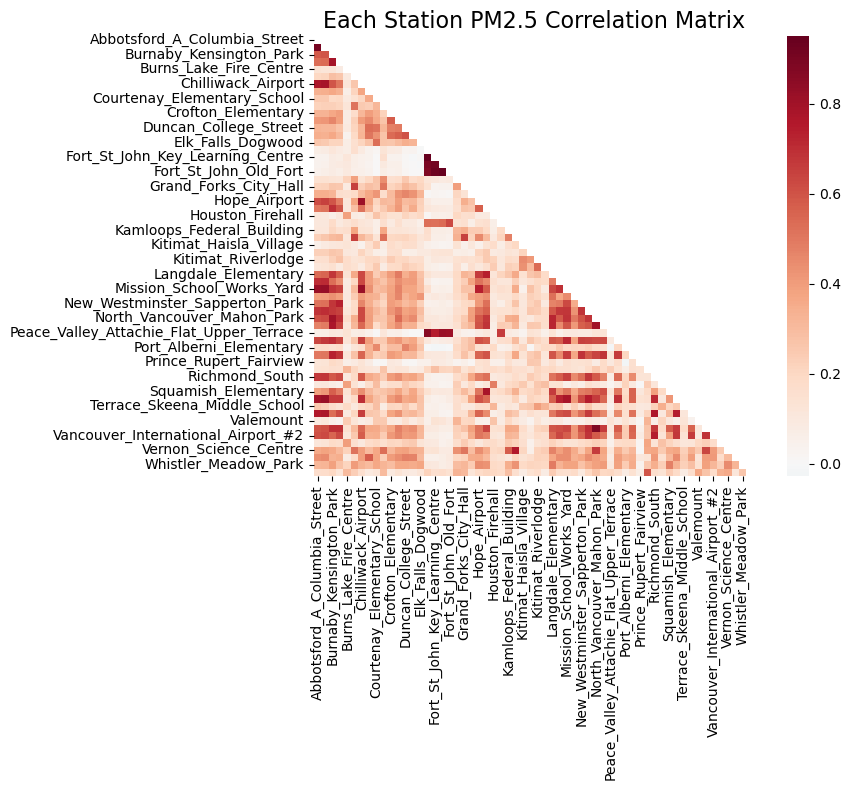

In [110]:
# Visualize the correlation matrix
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=False, 
            cmap='RdBu_r', 
            center=0,
            square=True)
plt.title('Each Station PM2.5 Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()
